In [6]:
import cv2, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path(r"./")   # 데이터 폴더 위치

df = pd.read_csv(DATA / "train.csv")
df[["x", "y", "w", "h"]] = np.array([json.loads(b) for b in df.bbox])
groups = dict(tuple(df.groupby("image_id")))   # 이미지별 박스 묶음

# 한글 경로에서는 cv2.imread 가 안 돼서 이렇게 읽음
def imread(path):
    return cv2.imdecode(np.fromfile(str(path), np.uint8), cv2.IMREAD_COLOR)

print(df.head())
print("박스 있는 이미지 수:", df.image_id.nunique())

    image_id  width  height                         bbox   source      x  \
0  b6ab77fd7   1024    1024   [834.0, 222.0, 56.0, 36.0]  usask_1  834.0   
1  b6ab77fd7   1024    1024  [226.0, 548.0, 130.0, 58.0]  usask_1  226.0   
2  b6ab77fd7   1024    1024  [377.0, 504.0, 74.0, 160.0]  usask_1  377.0   
3  b6ab77fd7   1024    1024  [834.0, 95.0, 109.0, 107.0]  usask_1  834.0   
4  b6ab77fd7   1024    1024  [26.0, 144.0, 124.0, 117.0]  usask_1   26.0   

       y      w      h  
0  222.0   56.0   36.0  
1  548.0  130.0   58.0  
2  504.0   74.0  160.0  
3   95.0  109.0  107.0  
4  144.0  124.0  117.0  
박스 있는 이미지 수: 3373


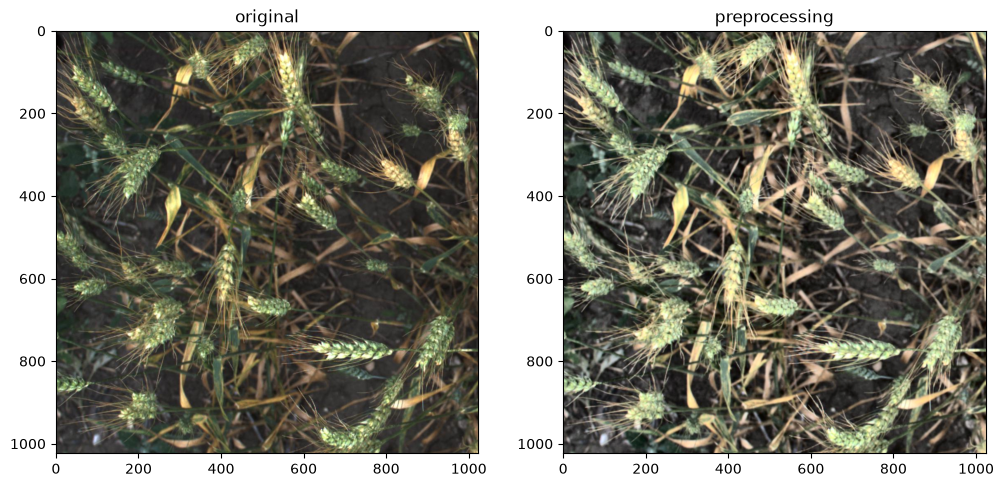

In [8]:
P = {
    "gaussian_k": 3,     # 블러 크기 (홀수, 1이면 안 씀)
    "clahe_clip": 2.0,   # 대비 보정 세기 (0이면 안 씀)
    "use_gray": False,   # 흑백 변환
}

def preprocess(img):
    if P["gaussian_k"] > 1:
        img = cv2.GaussianBlur(img, (P["gaussian_k"], P["gaussian_k"]), 0)
    if P["clahe_clip"] > 0:
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        lab[..., 0] = cv2.createCLAHE(P["clahe_clip"], (8, 8)).apply(lab[..., 0])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    if P["use_gray"]:
        img = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
    return img

# 원본 vs 전처리 비교
img = imread(DATA / "train" / f"{df.image_id.iloc[0]}.jpg")
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("original")
ax[1].imshow(cv2.cvtColor(preprocess(img), cv2.COLOR_BGR2RGB)); ax[1].set_title("preprocessing")
plt.show()

In [9]:
import random
ids = df.image_id.unique().tolist()
random.seed(0); random.shuffle(ids)
val_ids, train_ids = ids[:300], ids[300:]

for split, id_list in [("train", train_ids), ("val", val_ids)]:
    Path(f"yolo/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"yolo/labels/{split}").mkdir(parents=True, exist_ok=True)
    for i in id_list:
        img = preprocess(imread(DATA / "train" / f"{i}.jpg"))
        cv2.imencode(".jpg", img)[1].tofile(f"yolo/images/{split}/{i}.jpg")
        lines = [f"0 {(x + w/2)/1024} {(y + h/2)/1024} {w/1024} {h/1024}"
                 for x, y, w, h in groups[i][["x", "y", "w", "h"]].values]
        open(f"yolo/labels/{split}/{i}.txt", "w").write("\n".join(lines))

open("yolo/data.yaml", "w").write(
    f"path: {Path('yolo').resolve()}\ntrain: images/train\nval: images/val\nnames:\n  0: wheat\n")
print("완료")

완료


In [11]:
yaml_text = f"path: {Path('yolo').resolve()}\ntrain: images/train\nval: images/val\nnames:\n  0: wheat\n"
open("yolo/data.yaml", "w", encoding="utf-8").write(yaml_text)

# 확인용: 이미지가 제대로 만들어졌는지
print(yaml_text)
print("train 이미지:", len(list(Path("yolo/images/train").glob("*.jpg"))))
print("val 이미지:", len(list(Path("yolo/images/val").glob("*.jpg"))))

path: C:\Users\육군5군단PC_28\Desktop\wheat\yolo
train: images/train
val: images/val
names:
  0: wheat

train 이미지: 3073
val 이미지: 300


In [23]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")   # n이 가장 빠름. 성능 올릴 땐 s, m 으로
model.train(data="yolo/data.yaml", imgsz=512, epochs=3, batch=16, workers=0)

Ultralytics 8.4.173  Python-3.12.10 torch-2.14.1+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=None, opset=None, optimize=False, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025000E1E1B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [19]:
model = YOLO("runs/detect/train-5/weights/best.pt")   # 학습 결과 폴더 확인

CONF = 0.4       # 이 확신도 미만 박스 버림
IOU = 0.5        # 겹친 박스 제거 기준
MIN_AREA = 100   # 너무 작은 박스 버림

def count_match(pred, gt, thr=0.5):
    used, tp = set(), 0
    for p in pred:
        for j, g in enumerate(gt):
            if j in used: continue
            ix = max(0, min(p[2], g[2]) - max(p[0], g[0]))
            iy = max(0, min(p[3], g[3]) - max(p[1], g[1]))
            inter = ix * iy
            union = (p[2]-p[0])*(p[3]-p[1]) + (g[2]-g[0])*(g[3]-g[1]) - inter
            if inter / union >= thr:
                used.add(j); tp += 1; break
    return tp

rows = []
for i in val_ids:
    img = preprocess(imread(DATA / "train" / f"{i}.jpg"))
    r = model.predict(img, imgsz=1024, conf=CONF, iou=IOU, verbose=False)[0]
    pred = r.boxes.xyxy.cpu().numpy()
    pred = pred[(pred[:, 2]-pred[:, 0]) * (pred[:, 3]-pred[:, 1]) >= MIN_AREA]
    gt = groups[i][["x", "y", "w", "h"]].values.copy()
    gt[:, 2] += gt[:, 0]; gt[:, 3] += gt[:, 1]
    tp = count_match(pred, gt)
    rows.append({"image_id": i, "pred": len(pred), "gt": len(gt), "tp": tp,
                 "acc": tp / (len(pred) + len(gt) - tp)})

res = pd.DataFrame(rows)
print("식별한 이미지 수:", (res["pred"] > 0).sum(), "/", len(res))
print("예측 박스:", res["pred"].sum(), "/ 정답 박스:", res["gt"].sum())
print("accuracy:", round(res["acc"].mean(), 4))
print(res.sort_values("acc").head(10))   # 가장 많이 틀린 이미지 10장

식별한 이미지 수: 297 / 300
예측 박스: 7350 / 정답 박스: 13121
accuracy: 0.3167
      image_id  pred  gt  tp  acc
110  bebf1704f     0   3   0  0.0
289  a76ca8630     2   9   0  0.0
205  cb0a32cbb     1  12   0  0.0
272  b70b381d0     1  11   0  0.0
296  0e0809a3d     2  21   0  0.0
7    4e6c05213     1   1   0  0.0
59   b56668db8     2  23   0  0.0
154  ecebd6179     0   6   0  0.0
85   475d3a571     0  11   0  0.0
148  ac1e7253a     3   9   0  0.0


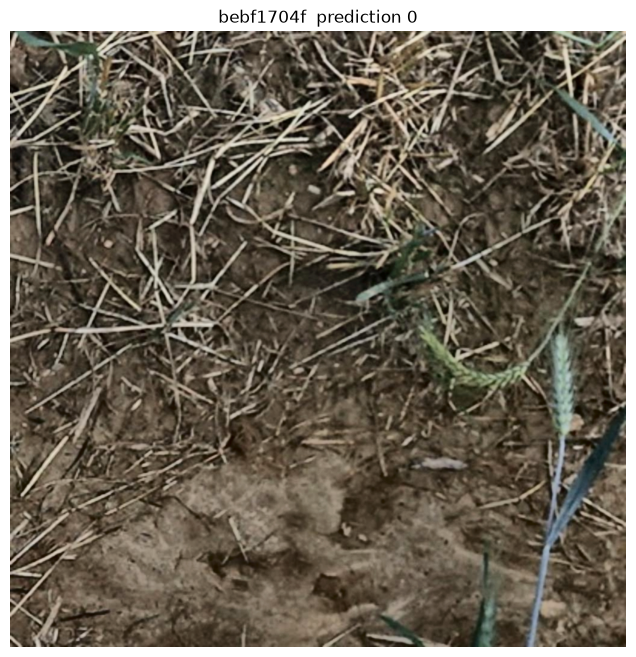

In [21]:
def show(i):
    img = preprocess(imread(DATA / "train" / f"{i}.jpg"))
    r = model.predict(img, imgsz=1024, conf=CONF, iou=IOU, verbose=False)[0]
    for x1, y1, x2, y2 in r.boxes.xyxy.cpu().numpy().astype(int):
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)   # 초록 = 예측
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{i}  prediction {len(r.boxes)}"); plt.axis("off"); plt.show()

show(res.sort_values("acc").image_id.iloc[0])   # 원하는 image_id 넣으면 됨

In [22]:
sub = pd.read_csv(DATA / "sample_submission.csv")
out = []
for i in sub.image_id:
    img = preprocess(imread(DATA / "test" / f"{i}.jpg"))
    r = model.predict(img, imgsz=1024, conf=CONF, iou=IOU, verbose=False)[0]
    parts = [f"{s:.4f} {int(x1)} {int(y1)} {int(x2-x1)} {int(y2-y1)}"
             for (x1, y1, x2, y2), s in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy())]
    out.append(" ".join(parts))
sub["PredictionString"] = out
sub.to_csv("submission.csv", index=False)
print(sub)

    image_id                                   PredictionString
0  aac893a91  0.4844 362 538 88 66 0.4837 992 270 31 34 0.43...
1  51f1be19e  0.5226 698 627 65 42 0.4812 583 37 33 31 0.479...
2  f5a1f0358                               0.5179 421 180 52 44
3  796707dd7                                 0.5285 0 772 31 34
4  51b3e36ab  0.5088 490 584 64 51 0.4495 383 431 96 63 0.44...
5  348a992bb  0.7673 699 50 61 44 0.6807 901 993 61 30 0.506...
6  cc3532ff6                                 0.4635 0 100 30 27
7  2fd875eaa  0.6661 243 1002 61 21 0.6545 790 731 94 69 0.6...
8  cb8d261a3  0.5271 466 125 85 40 0.5151 651 683 90 59 0.49...
9  53f253011                               0.4504 636 113 98 76
